In [3]:
import numpy as np
import pandas as pd
import os
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import pickle


In [4]:
dataset_dir = 'dataset/our_data'

datasets = os.listdir(dataset_dir)
datasets_df = pd.DataFrame({'filenames': datasets})

In [5]:
datasets_df

,filenames
0,JonnyConfused2.csv
1,CooperConfused_2.csv
2,JonnyUnderstanding.csv
3,CooperControl2.csv
4,JonnyControl.csv
5,JoshUnderstanding.csv
6,JonnyConfused.csv
7,CooperUnderstanding.csv
8,JoshControl.csv
9,CooperUnderstanding2.csv


In [6]:
def transform_set(scalar, data, fit=False):
    original_shape = data.shape 
    reshaped = data.reshape(-1, data.shape[-1]) 

    if fit:
        reshaped = scalar.fit_transform(reshaped)
    else:
        reshaped = scalar.transform(reshaped)
        
    reshaped = reshaped.reshape(original_shape)

    return reshaped

In [228]:
def preprocess():

    classes = ['confused', 'control', 'understanding']
    datasets_by_class = {'confused':[], 'control':[], 'understanding':[]}
    test_sets_by_class = {'confused':[], 'control':[], 'understanding':[]}
    window_size = 512 #samples
    total_samples = 0

    for class_name in classes:
        datasets = datasets_df[datasets_df['filenames'].str.contains(class_name, case=False)]

        for filename in datasets['filenames']:
            if not ("Jonny" in filename):# and "2" in filename):
                continue

            sub_df = pd.read_csv(f"{dataset_dir}/{filename}") 
            # sub_df = sub_df.iloc[3200:-3200]
            total_samples+=sub_df.shape[0]
            # cutoff = int(sub_df.shape[0]*0.80)
            # train_raw, test_raw = sub_df.iloc[:cutoff], sub_df.iloc[cutoff:]
            c1 = int(sub_df.shape[0]*0.4)
            c2 = int(sub_df.shape[0]*0.6)
            train_raw, test_raw = pd.concat((sub_df.iloc[:c1],sub_df.iloc[c2:])), sub_df.iloc[c1:c2]

            """# NOTE: Split the data after reading, THEN perform sliding window
            windows = []
            row = 0
            while row+window_size < raw.shape[0]:
                windows.append(raw.iloc[row:row+window_size])
                row+=(1*window_size)

            print(np.array(windows).shape)
            # TODO: check if this is doing things on the wrong axis
            train_windows, test_windows = train_test_split(windows, test_size=0.2)"""

            # TRAINING DATA
            train_windows = []
            row=0
            while row+window_size < train_raw.shape[0]:
                train_windows.append(train_raw.iloc[row:row+window_size])
                row+=int(window_size*0.1)

            # Testing Data
            test_windows = []
            row=0
            while row+window_size < test_raw.shape[0]:
                test_windows.append(test_raw.iloc[row:row+window_size])
                row+=int(window_size*0.1)
            

            datasets_by_class[class_name]+=train_windows
            test_sets_by_class[class_name]+=test_windows


    # Training set asarray
    confused_train_data = np.asarray(datasets_by_class['confused'], dtype='object')
    control_train_data = np.asarray(datasets_by_class['control'], dtype='object')
    understanding_train_data = np.asarray(datasets_by_class['understanding'], dtype='object')

    # Test set asarray
    confused_test_data = np.asarray(test_sets_by_class['confused'], dtype='object')
    control_test_data = np.asarray(test_sets_by_class['control'], dtype='object')
    understanding_test_data = np.asarray(test_sets_by_class['understanding'], dtype='object')


    X_train = confused_train_data[:, :, 1:5]  # Remove the first column
    X_train = np.concatenate([X_train, control_train_data[:, :, 1:5]], axis=0)
    X_train = np.concatenate([X_train, understanding_train_data[:, :, 1:5]], axis=0)

    X_test = confused_test_data[:, :, 1:5]  # Remove the first column
    X_test = np.concatenate([X_test, control_test_data[:, :, 1:5]], axis=0)
    X_test = np.concatenate([X_test, understanding_test_data[:, :, 1:5]], axis=0)


    # Confused: [1,0,0]
    # Control: [0,1,0]
    # Understanding: [0,0,1]

    y_train = np.array(
        np.concatenate(([[1,0,0]] * confused_train_data[:, :, 1:5].shape[0],
                        [[0,1,0]] * control_train_data[:, :, 1:5].shape[0],
                        [[0,0,1]] * understanding_train_data[:, :, 1:5].shape[0])))
    
    y_test = np.array(
        np.concatenate(([[1,0,0]] * confused_test_data[:, :, 1:5].shape[0],
                        [[0,1,0]] * control_test_data[:, :, 1:5].shape[0],
                        [[0,0,1]] * understanding_test_data[:, :, 1:5].shape[0])))

    '''y_train = np.array(
        np.concatenate(([[0,1]] * confused_train_data[:, :, 1:5].shape[0],
                        [[1,0]] * control_train_data[:, :, 1:5].shape[0])))
    
    y_test = np.array(
        np.concatenate(([[0,1]] * confused_test_data[:, :, 1:5].shape[0],
                        [[1,0]] * control_test_data[:, :, 1:5].shape[0])))'''



    # Shuffle train and test set separately
    X_train, y_train = shuffle(X_train, y_train)
    X_test, y_test = shuffle(X_test, y_test)

    # Normalize data
    # X_scalar = MinMaxScaler()
    X_scalar = RobustScaler()
    X_train_scaled = transform_set(X_scalar, X_train, fit=True)
    X_test_scaled = transform_set(X_scalar, X_test, fit=False)

    with open('models/X_scalar.pckl', 'wb') as file:
        # Pickle the data and write it to the file
        pickle.dump(X_scalar, file)
    print(total_samples)
    return X_train_scaled, X_test_scaled, y_train, y_test
    # return X_train, X_test, y_train, y_test

In [229]:
X_train_scaled, X_test_scaled, y_train, y_test = preprocess()
# preprocess()

269782


In [190]:
X_train_scaled.shape

(2774, 256, 4)

In [191]:
X_test_scaled.shape

(672, 256, 4)

In [80]:
y_train[0]

np.int64(0)

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import regularizers

2025-04-01 17:37:04.034703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743554224.047229   29719 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743554224.050818   29719 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743554224.066703   29719 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743554224.066727   29719 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743554224.066729   29719 computation_placer.cc:177] computation placer alr

In [ ]:
# Define the input shape (256x4)
input_shape = (512, 4) 

# Build the CNN model
'''model = keras.Sequential([
    layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=5, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
    layers.Dense(1, activation='sigmoid')  # Two output neurons for two classes
])'''


model = keras.Sequential([
    layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=6, activation='relu', kernel_regularizer=regularizers.l2(0.003)),
    layers.Dropout(0.6),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=7, activation='relu', kernel_regularizer=regularizers.l2(0.003)),
    layers.Dropout(0.5),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=8, activation='relu', kernel_regularizer=regularizers.l2(0.003)),
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    # layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')  # Two output neurons for two classes
])

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
# model.summary()

/home/babybacon/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
filepath = "models/3_output_model_jonny_3.keras"
checkpoint = ModelCheckpoint(
    filepath, 
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True,
    mode='max'
)


model.fit(X_train_scaled, y_train, epochs=200, validation_data=(X_test_scaled, y_test), callbacks=[checkpoint])

Epoch 1/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3672 - loss: 1.6934
Epoch 1: val_accuracy improved from -inf to 0.34431, saving model to models/3_output_model_jonny_3.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.3672 - loss: 1.6927 - val_accuracy: 0.3443 - val_loss: 1.4806
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4197 - loss: 1.4114
Epoch 2: val_accuracy improved from 0.34431 to 0.52495, saving model to models/3_output_model_jonny_3.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4200 - loss: 1.4109 - val_accuracy: 0.5250 - val_loss: 1.2673
Epoch 3/200
125/131 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5385 - loss: 1.1913
Epoch 3: val_accuracy improved from 0.52495 to 0.55190, saving model to models/3_output_model_jonny_3.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5391 - loss: 1.1894 - val_accuracy: 0.5519 - val_loss: 1.1677
Epoch 4/200
129/131 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

In [ ]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(6705, 256, 4)
(1152, 256, 4)


In [134]:
loaded = keras.models.load_model('models/3_output_model_jonny_3.keras', custom_objects=None, compile=True, safe_mode=True)

preds = loaded.predict(X_test_scaled)

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [47]:
preds[0]

array([0.37660962, 0.00233171, 0.62105864], dtype=float32)

In [87]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [10]:
def plotit(sample):
    plt.imshow(sample, cmap='twilight', interpolation='nearest', aspect='auto')
    plt.show()


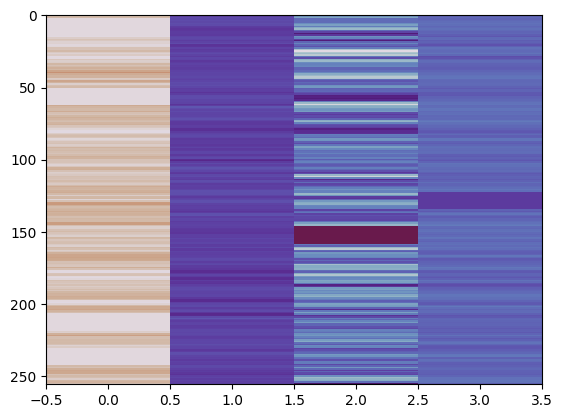

In [14]:
plotit(X_train_scaled[-10])

In [135]:
score = 0
# TODO: USE ARGMAX
for i in range(preds.shape[0]):
    is_equal = np.equal(np.round(preds[i]), np.round(y_test[i]))
    if is_equal.all():
        score+=1
        # print(preds[i])
        # plotit(X_test_scaled[i])

print(f"{score}/{preds.shape[0]}")

2836/3160


IndexError: index 4986 is out of bounds for axis 0 with size 4986

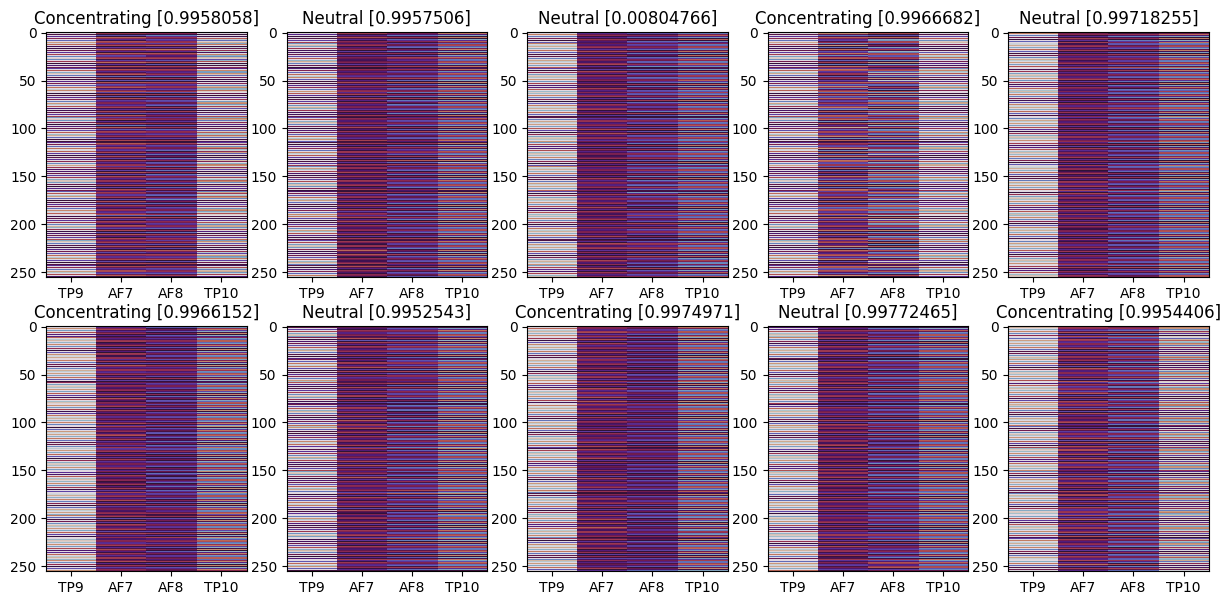

In [ ]:

# Assuming X_test_scaled and y_test are already defined, and each image is 2D
fig, axes = plt.subplots(2, 5, figsize=(15, 7))  # Create a 2x5 grid of subplots
axes = axes.flatten()  # Flatten the 2D array of axes to easily iterate through it


positives = 0
negatives = 0

i = 20
while positives<2 or negatives<8:

    if (y_train[i] == 1 and positives<5) or (y_train[i] == 0 and negatives<5):
        ax = axes[positives+negatives]  # Select the subplot for the current image
        ax.imshow(X_train_scaled[i], cmap='twilight', interpolation='nearest', aspect='auto')
        ax.set_title(
            f'Concentrating {preds[i]}' if y_train[i]==[] else f'Neutral {preds[i]}'
            )  # Set title with the label
        # ax.axis('off')  # Hide axis for a cleaner look
        ax.set_xticks([0,1,2,3])
        ax.set_xticklabels(['TP9','AF7','AF8','TP10'])

        positives+=int(y_train[i]==1)
        negatives+=int(y_train[i]==0)

    i+=1

# Show the plot
# plt.savefig('classes_shuffled_data.png')
plt.show()

In [88]:
def plot_sample(sample):
    variables = ['TP9','AF7','AF8','TP10']
    # Number of samples
    num_samples = sample.shape[0]

    # Create a figure with 5 subplots (1 column and 5 rows)
    fig, axes = plt.subplots(4, 1, figsize=(10, 15))

    # Plot each of the 5 variables in separate subplots
    for i in range(sample.shape[1]):
        axes[i].plot(range(num_samples), sample[:, i], label=f'Variable {i+1}')
        axes[i].set_title(f'{variables[i]}')
        axes[i].set_ylabel('Value')
        axes[i].legend()

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Display the plot
    plt.show()

[1 0 0]


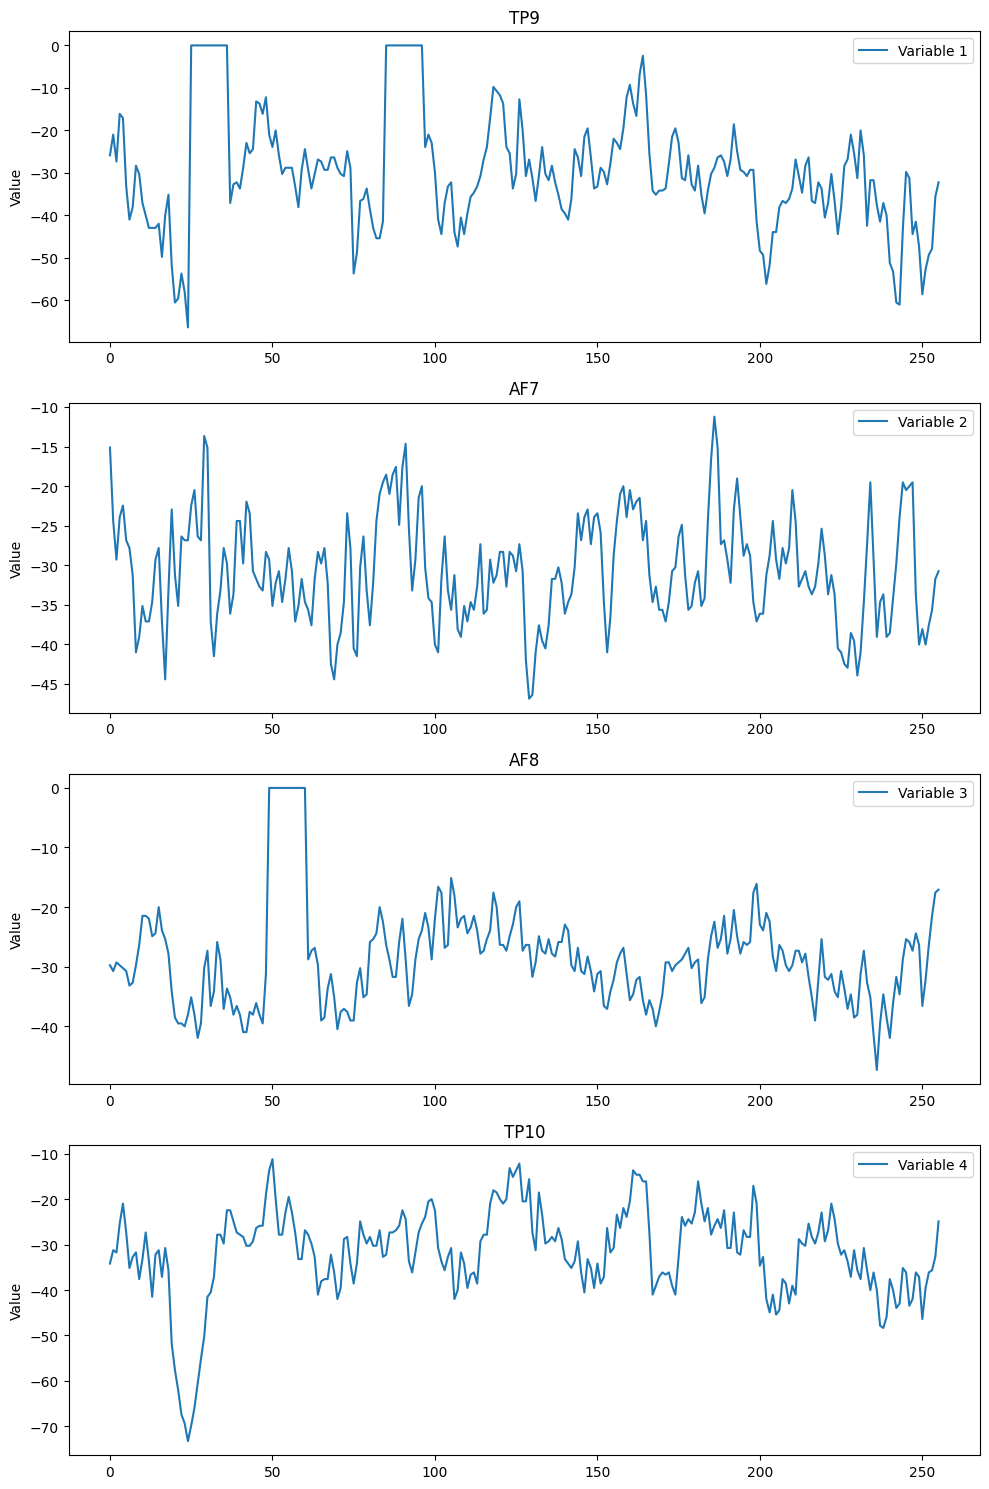

In [116]:
a = 1
print(y_train[a])
plot_sample(X_train_scaled[a])

In [ ]:
eeg_data = X_train_scaled[1]  # Simulated EEG data

eeg_data = eeg_data.reshape(4,256)